# Tehnike za augmentaciju tekstualnih podataka

Praktični deo seminarskog rada prikazuje uticaj više tehnika augmentacije na klasifikaciju sentimenta korisničkih recenzija.

Eksperiment je organizovan u dva nivoa:

1. **Brze tehnike** - generiše se veći broj primera jer ne zahtevaju neuronske modele.
2. **Napredne tehnike** - koristi se manji, ali isti budžet novih primera za svaku metodu, kako bi poređenje ostalo izvodljivo na CPU-u.

Za svako poređenje koriste se:
- isti originalni train/test split,
- nepromenjen test skup,
- isti TF-IDF + logistička regresija klasifikator,
- isti broj novih primera unutar posmatrane grupe eksperimenata.

Prate se `Accuracy`, `Macro F1` i posebno `Neutral F1`, zato što je neutralna klasa najmanje zastupljena i predstavlja cilj augmentacije.

## 1. Skup podataka

Koristi se Kaggle skup **McDonald's Store Reviews**:

https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-reviews

Za eksperiment su potrebne kolone:
- `review` - tekst recenzije,
- `rating` - ocena od 1 do 5 zvezdica.

Ocene se grupišu u tri klase sentimenta:

- **1–2 zvezdice: negative**
- **3 zvezdice: neutral**
- **4–5 zvezdica: positive**

In [1]:
import json
import os
import random
import re
import time
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Budžeti su podešeni tako da ceo eksperiment bude realan za CPU.
N_QUICK = 1000
N_ADVANCED = 500

print("Budžet brzih tehnika:", N_QUICK)
print("Budžet naprednih tehnika:", N_ADVANCED)

Budžet brzih tehnika: 1000
Budžet naprednih tehnika: 500


## 2. Učitavanje i priprema podataka

Predobrada je namerno blaga. Negacije i stop-reči se ne uklanjaju jer mogu biti važne za sentiment.

Uklanjaju se URL adrese, HTML oznake, oštećeni karakteri nastali pri dekodiranju i višestruki razmaci. Duplikati se uklanjaju pre train/test podele kako isti tekst ne bi završio u oba skupa.

In [2]:
DATA_PATH = "McDonald_s_Reviews.csv"

data_raw = pd.read_csv(DATA_PATH, encoding="latin1")

print("Dimenzije originalnog skupa:", data_raw.shape)
print("Kolone:", data_raw.columns.tolist())

pd.set_option("display.max_colwidth", None)

display(
    data_raw.head().style.set_properties(
        subset=["review"],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "500px",
        }
    )
)

Dimenzije originalnog skupa: (33396, 10)
Kolone: ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating']


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,"Why does it look like someone spit on my food? I had a normal transaction, everyone was chill and polite, but now i dont want to eat this. Im trying not to think about what this milky white/clear substance is all over my food, i d*** sure am not coming back.",1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,"It'd McDonalds. It is what it is as far as the food and atmosphere go. The staff here does make a difference. They are all friendly, accommodating and always smiling. Makes for a more pleasant experience than many other fast food places.",4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and checked it in. Line was not moving so I had to leave otherwise Iï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½d be late for work. Never got the refund in the app. I called them and they said I could only get my money back in person because it was stuck in the system. Went there in person the next day and the manager told me she wasnï¿,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ customer service was quick and p,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, and she still manage to mess it up , it was suppose to be a large meal double filet of fish with large fries , no cheese . It was all wrong , they either need to pay close attention to the order being made , understand English or they need not to work at a drive thru",1 star


In [3]:
data = data_raw[["review", "rating"]].copy()

data["rating_num"] = (
    data["rating"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

data["sentiment"] = data["rating_num"].map({
    1: "negative",
    2: "negative",
    3: "neutral",
    4: "positive",
    5: "positive",
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"(?:ï¿½|�|ý)+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data["text"] = data["review"].apply(clean_text)
data = data[data["text"].str.len() > 0].copy()

before_dedup = len(data)

data = data.drop_duplicates(
    subset=["text", "sentiment"]
).copy()

sentiments_per_text = (
    data.groupby("text")["sentiment"].nunique()
)

conflicting_texts = sentiments_per_text[
    sentiments_per_text > 1
].index

data = data[
    ~data["text"].isin(conflicting_texts)
].reset_index(drop=True)

data["word_count"] = data["text"].str.split().str.len()

print("Broj redova pre uklanjanja duplikata:", before_dedup)
print("Broj redova nakon čišćenja:", len(data))
print("Broj tekstova sa konfliktnim sentiment oznakama:", len(conflicting_texts))

Broj redova pre uklanjanja duplikata: 33348
Broj redova nakon čišćenja: 21913
Broj tekstova sa konfliktnim sentiment oznakama: 157


### 2.1. Raspodela klasa

,Broj primera
sentiment,
positive,9501
negative,9352
neutral,3060


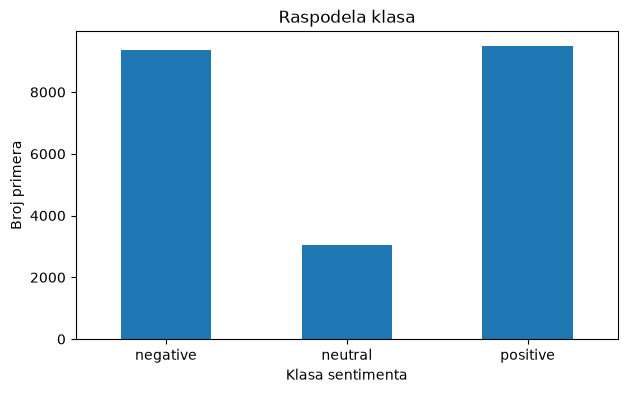

In [4]:
class_counts = data["sentiment"].value_counts()
display(class_counts.rename("Broj primera").to_frame())

class_counts.reindex(
    ["negative", "neutral", "positive"]
).plot(
    kind="bar",
    figsize=(7, 4),
)

plt.xlabel("Klasa sentimenta")
plt.ylabel("Broj primera")
plt.title("Raspodela klasa")
plt.xticks(rotation=0)
plt.show()

Neutralna klasa je najmanje zastupljena, pa se sintetički primeri generišu samo za nju. Time augmentacija ima jasno definisan cilj: povećanje raznovrsnosti manjinske klase bez menjanja test skupa.

### 2.2. Dužina recenzija

,Broj reči
count,21913.000000
mean,26.143476
std,34.123676
min,1.000000
25%,7.000000
50%,15.000000
75%,32.000000
max,589.000000


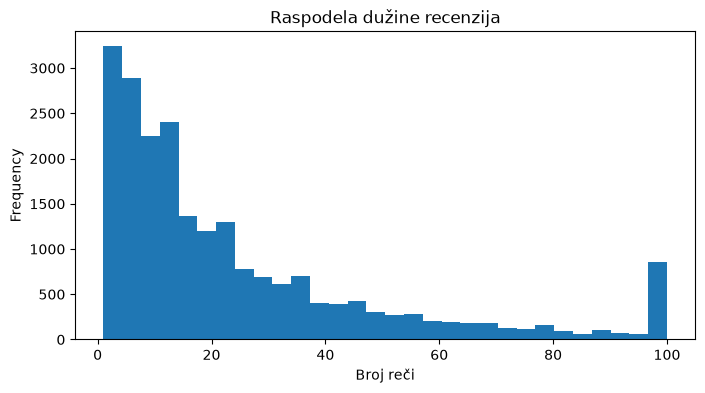

In [5]:
display(
    data["word_count"]
    .describe()
    .rename("Broj reči")
    .to_frame()
)

data["word_count"].clip(upper=100).plot(
    kind="hist",
    bins=30,
    figsize=(8, 4),
)

plt.xlabel("Broj reči")
plt.title("Raspodela dužine recenzija")
plt.show()

## 3. Train/test podela

Podela se radi pre augmentacije. Sintetički primeri nastaju isključivo iz trening skupa.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["sentiment"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=data["sentiment"],
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train:", len(X_train))
print("Test:", len(X_test))
display(
    y_train.value_counts()
    .rename("Train primeri")
    .to_frame()
)

Train: 17530
Test: 4383


,Train primeri
sentiment,
positive,7601
negative,7481
neutral,2448


## 4. Bazni model i evaluacija

Za sva poređenja koristi se:

**TF-IDF → logistička regresija**

Na ovaj način između eksperimenata se menja samo trening skup, a klasifikacioni model ostaje isti.

`Macro F1` je glavna metrika za poređenje zato što svim klasama daje jednaku važnost. `Neutral F1` pokazuje da li augmentacija zaista poboljšava prepoznavanje neutralnih recenzija.

In [7]:
def create_classifier():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1500,
                random_state=RANDOM_STATE,
            ),
        ),
    ])

all_results = []
experiment_predictions = {}

def evaluate_experiment(
    group_name,
    method_name,
    X_train_exp,
    y_train_exp,
    n_augmented=0,
    generation_seconds=0.0,
):
    model = create_classifier()

    start = time.perf_counter()
    model.fit(X_train_exp, y_train_exp)
    predictions = model.predict(X_test)
    training_seconds = time.perf_counter() - start

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0,
    )

    row = {
        "Grupa": group_name,
        "Metoda": method_name,
        "Broj novih primera": n_augmented,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
        ),
        "Neutral F1": report["neutral"]["f1-score"],
        "Generisanje [s]": generation_seconds,
        "Trening [s]": training_seconds,
    }

    all_results.append(row)
    experiment_predictions[
        f"{group_name} | {method_name}"
    ] = predictions

    print(
        f"{method_name}: "
        f"macro F1={row['Macro F1']:.3f}, "
        f"neutral F1={row['Neutral F1']:.3f}"
    )

    return model

In [8]:
baseline_model = evaluate_experiment(
    "Baseline",
    "Bez augmentacije",
    X_train,
    y_train,
)

print()
print(classification_report(
    y_test,
    experiment_predictions[
        "Baseline | Bez augmentacije"
    ],
    digits=3,
    zero_division=0,
))

Bez augmentacije: macro F1=0.622, neutral F1=0.188

              precision    recall  f1-score   support

    negative      0.787     0.906     0.842      1871
     neutral      0.468     0.118     0.188       612
    positive      0.800     0.874     0.835      1900

    accuracy                          0.782      4383
   macro avg      0.685     0.632     0.622      4383
weighted avg      0.748     0.782     0.748      4383



## 5. Brze tehnike augmentacije

Ovaj deo obuhvata EDA tehnike i karakterski šum. Za svaku metodu generiše se tačno `N_QUICK` novih neutralnih primera.

Kao kontrola se koristi nasumični oversampling postojećih neutralnih primera sa istim budžetom. Na taj način može da se razlikuje efekat novih tekstualnih varijacija od efekta samog povećanja broja primera.

In [9]:
import nltk
from nltk.corpus import wordnet

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

NEGATIONS = {
    "no", "not", "never", "none", "nothing",
    "neither", "nor", "cannot", "can't",
    "dont", "don't", "didn't", "doesn't",
    "isn't", "wasn't", "weren't", "won't",
}

def tokenize_words(text):
    return re.findall(
        r"[a-z]+(?:'[a-z]+)?",
        text.lower(),
    )

@lru_cache(maxsize=15000)
def get_synonyms(word):
    synonyms = set()

    for synset in wordnet.synsets(word):
        for lemma in synset.lemmas():
            candidate = (
                lemma.name()
                .replace("_", " ")
                .lower()
            )

            if (
                candidate != word.lower()
                and " " not in candidate
                and candidate.isalpha()
            ):
                synonyms.add(candidate)

    return sorted(synonyms)

In [10]:
def synonym_replacement(text, rng, alpha=0.10):
    words = tokenize_words(text)

    candidates = [
        i for i, word in enumerate(words)
        if (
            word not in NEGATIONS
            and get_synonyms(word)
        )
    ]

    if not candidates:
        return text

    rng.shuffle(candidates)
    n_replace = max(
        1,
        round(alpha * len(words)),
    )

    new_words = words.copy()

    for index in candidates[:n_replace]:
        new_words[index] = rng.choice(
            get_synonyms(words[index])
        )

    return " ".join(new_words)


def random_insertion(text, rng, n=1):
    words = tokenize_words(text)

    source_words = [
        word for word in words
        if (
            word not in NEGATIONS
            and get_synonyms(word)
        )
    ]

    if not source_words:
        return text

    new_words = words.copy()

    for _ in range(n):
        source_word = rng.choice(source_words)
        synonym = rng.choice(
            get_synonyms(source_word)
        )
        position = rng.randint(
            0,
            len(new_words),
        )
        new_words.insert(position, synonym)

    return " ".join(new_words)


def random_deletion(text, rng, p=0.10):
    words = tokenize_words(text)

    if len(words) <= 1:
        return text

    kept = [
        word
        for word in words
        if (
            word in NEGATIONS
            or rng.random() > p
        )
    ]

    if not kept:
        kept = [rng.choice(words)]

    return " ".join(kept)


def random_swap(text, rng, n=1):
    words = tokenize_words(text)

    movable = [
        i for i, word in enumerate(words)
        if word not in NEGATIONS
    ]

    if len(movable) < 2:
        return text

    new_words = words.copy()

    for _ in range(n):
        i, j = rng.sample(movable, 2)
        new_words[i], new_words[j] = (
            new_words[j],
            new_words[i],
        )

    return " ".join(new_words)


def character_noise(text, rng):
    words = text.split()

    candidates = [
        i for i, word in enumerate(words)
        if len(
            re.sub(r"[^a-zA-Z]", "", word)
        ) >= 4
    ]

    if not candidates:
        return text

    word_index = rng.choice(candidates)
    word = words[word_index]

    positions = [
        i for i in range(len(word) - 1)
        if (
            word[i].isalpha()
            and word[i + 1].isalpha()
        )
    ]

    if not positions:
        return text

    i = rng.choice(positions)
    chars = list(word)
    chars[i], chars[i + 1] = (
        chars[i + 1],
        chars[i],
    )

    words[word_index] = "".join(chars)

    return " ".join(words)


def combined_eda(text, rng):
    methods = [
        synonym_replacement,
        random_insertion,
        random_deletion,
        random_swap,
    ]

    return rng.choice(methods)(text, rng)

In [11]:
TARGET_CLASS = "neutral"

def oversample_training_set(n_new, seed):
    source_indices = y_train[
        y_train == TARGET_CLASS
    ].index

    sampled_indices = (
        pd.Series(source_indices)
        .sample(
            n=n_new,
            replace=True,
            random_state=seed,
        )
        .to_numpy()
    )

    X_new = X_train.iloc[
        sampled_indices
    ].reset_index(drop=True)

    X_exp = pd.concat(
        [X_train, X_new],
        ignore_index=True,
    )

    y_exp = pd.concat(
        [
            y_train,
            pd.Series(
                [TARGET_CLASS] * len(X_new)
            ),
        ],
        ignore_index=True,
    )

    return X_exp, y_exp


def create_augmented_training_set(
    augment_fn,
    n_new,
    seed,
):
    rng = random.Random(seed)

    source_texts = X_train[
        y_train == TARGET_CLASS
    ].tolist()

    augmented = []
    attempts = 0
    max_attempts = n_new * 30

    while (
        len(augmented) < n_new
        and attempts < max_attempts
    ):
        original = rng.choice(source_texts)
        new_text = augment_fn(
            original,
            rng,
        ).strip()

        if (
            new_text
            and new_text != original
        ):
            augmented.append(new_text)

        attempts += 1

    X_exp = pd.concat(
        [
            X_train,
            pd.Series(augmented),
        ],
        ignore_index=True,
    )

    y_exp = pd.concat(
        [
            y_train,
            pd.Series(
                [TARGET_CLASS] * len(augmented)
            ),
        ],
        ignore_index=True,
    )

    return (
        X_exp,
        y_exp,
        len(augmented),
    )

### 5.1. Primeri brzih transformacija

In [12]:
demo_pool = data[
    (data["sentiment"] == "neutral")
    & (data["word_count"].between(8, 25))
]

demo_text = demo_pool.sample(
    1,
    random_state=RANDOM_STATE,
)["text"].iloc[0]

demo_rng = random.Random(RANDOM_STATE)

demo_methods = {
    "Zamena sinonimima": synonym_replacement,
    "Nasumično umetanje": random_insertion,
    "Nasumično brisanje": random_deletion,
    "Nasumična zamena mesta": random_swap,
    "Karakterski šum": character_noise,
    "Kombinovani EDA": combined_eda,
}

examples = [
    {
        "Metoda": "Original",
        "Tekst": demo_text,
    }
]

for method_name, augment_fn in demo_methods.items():
    examples.append({
        "Metoda": method_name,
        "Tekst": augment_fn(
            demo_text,
            demo_rng,
        ),
    })

examples_df = pd.DataFrame(examples)

display(
    examples_df.style.set_properties(
        subset=["Tekst"],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "700px",
        }
    )
)

,Metoda,Tekst
0,Original,"the inside says ""please dont walk through our drive thru"" but the customer base says ""i'm going to anyways"""
1,Zamena sinonimima,the inside says please dont walk through our aim thru but the client base says i'm going to anyways
2,Nasumično umetanje,the inside says please dont walk through enjoin our drive thru but the customer base says i'm going to anyways
3,Nasumično brisanje,the says please dont walk through our drive but the customer base says i'm anyways
4,Nasumična zamena mesta,the thru says please dont walk through our drive inside but the customer base says i'm going to anyways
5,Karakterski šum,"the inside says ""please dont walk through our drive thru"" but the customer base says ""i'm goign to anyways"""
6,Kombinovani EDA,the inside says please dont paseo through our drive thru but the client base says i'm going to anyways


### 5.2. Poređenje brzih metoda

Sve metode u ovoj tabeli dodaju isti broj novih primera (`N_QUICK`).

In [13]:
X_over, y_over = oversample_training_set(
    N_QUICK,
    RANDOM_STATE,
)

evaluate_experiment(
    "Brze metode",
    "Nasumični oversampling",
    X_over,
    y_over,
    n_augmented=N_QUICK,
)

quick_methods = {
    "Zamena sinonimima": synonym_replacement,
    "Nasumično umetanje": random_insertion,
    "Nasumično brisanje": random_deletion,
    "Nasumična zamena mesta": random_swap,
    "Karakterski šum": character_noise,
    "Kombinovani EDA": combined_eda,
}

for i, (
    method_name,
    augment_fn,
) in enumerate(quick_methods.items()):
    start = time.perf_counter()

    X_aug, y_aug, n_generated = (
        create_augmented_training_set(
            augment_fn,
            N_QUICK,
            RANDOM_STATE + i,
        )
    )

    generation_seconds = (
        time.perf_counter() - start
    )

    evaluate_experiment(
        "Brze metode",
        method_name,
        X_aug,
        y_aug,
        n_augmented=n_generated,
        generation_seconds=generation_seconds,
    )

Nasumični oversampling: macro F1=0.646, neutral F1=0.260
Zamena sinonimima: macro F1=0.644, neutral F1=0.259
Nasumično umetanje: macro F1=0.641, neutral F1=0.246
Nasumično brisanje: macro F1=0.643, neutral F1=0.253
Nasumična zamena mesta: macro F1=0.647, neutral F1=0.262
Karakterski šum: macro F1=0.644, neutral F1=0.256
Kombinovani EDA: macro F1=0.647, neutral F1=0.265


In [14]:
quick_results = pd.DataFrame(
    all_results
)

quick_results = quick_results[
    quick_results["Grupa"].isin(
        ["Baseline", "Brze metode"]
    )
].copy()

display(
    quick_results[
        [
            "Metoda",
            "Broj novih primera",
            "Accuracy",
            "Macro F1",
            "Neutral F1",
            "Generisanje [s]",
        ]
    ].style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "Neutral F1": "{:.3f}",
        "Generisanje [s]": "{:.1f}",
    })
)

,Metoda,Broj novih primera,Accuracy,Macro F1,Neutral F1,Generisanje [s]
0,Bez augmentacije,0,0.782,0.622,0.188,0.0
1,Nasumični oversampling,1000,0.781,0.646,0.260,0.0
2,Zamena sinonimima,1000,0.778,0.644,0.259,1.9
3,Nasumično umetanje,1000,0.778,0.641,0.246,0.4
4,Nasumično brisanje,1000,0.779,0.643,0.253,0.1
5,Nasumična zamena mesta,1000,0.779,0.647,0.262,0.0
6,Karakterski šum,1000,0.779,0.644,0.256,0.1
7,Kombinovani EDA,1000,0.779,0.647,0.265,0.2


## 6. Napredne tehnike – mali, jednak budžet

Napredne metode zahtevaju neuronske modele ili API pozive, pa se za njih koristi manji budžet `N_ADVANCED`.

Poređenje je i dalje fer: svaka napredna metoda dodaje isti broj novih neutralnih primera. U istoj grupi se ponovo prikazuju:
- nasumični oversampling sa `N_ADVANCED` primera,
- kombinovani EDA sa `N_ADVANCED` primera.

Ove dve metode služe kao kontrole za poređenje sa skupljim pristupima.

Za brže izvršavanje koriste se neutralne trening recenzije dužine 5–40 reči. Isti izvorni podskup koristi se kod svih naprednih metoda.

In [15]:
neutral_lengths = (
    X_train.str.split().str.len()
)

advanced_pool = X_train[
    (y_train == TARGET_CLASS)
    & neutral_lengths.between(5, 40)
].reset_index(drop=True)

# Uzima se nešto više izvora od potrebnog broja
# kako bi mogli da se odbace nepromenjeni izlazi.
N_ADVANCED_CANDIDATES = min(
    len(advanced_pool),
    N_ADVANCED + 50,
)

advanced_source_texts = (
    advanced_pool
    .sample(
        n=N_ADVANCED_CANDIDATES,
        random_state=RANDOM_STATE,
    )
    .tolist()
)

print(
    "Broj izvora za napredne metode:",
    len(advanced_source_texts),
)

Broj izvora za napredne metode: 550


In [16]:
def add_generated_examples(
    generated_texts,
    method_name,
    generation_seconds,
):
    cleaned = []

    for original, generated in generated_texts:
        generated = clean_text(generated)

        if (
            generated
            and generated != clean_text(original)
        ):
            cleaned.append(generated)

        if len(cleaned) == N_ADVANCED:
            break

    X_exp = pd.concat(
        [
            X_train,
            pd.Series(cleaned),
        ],
        ignore_index=True,
    )

    y_exp = pd.concat(
        [
            y_train,
            pd.Series(
                [TARGET_CLASS] * len(cleaned)
            ),
        ],
        ignore_index=True,
    )

    evaluate_experiment(
        "Napredne metode",
        method_name,
        X_exp,
        y_exp,
        n_augmented=len(cleaned),
        generation_seconds=generation_seconds,
    )

    return cleaned

### 6.1. Kontrole sa istim budžetom

In [17]:
X_over_adv, y_over_adv = (
    oversample_training_set(
        N_ADVANCED,
        RANDOM_STATE + 100,
    )
)

evaluate_experiment(
    "Napredne metode",
    "Nasumični oversampling",
    X_over_adv,
    y_over_adv,
    n_augmented=N_ADVANCED,
)

start = time.perf_counter()

X_eda_adv, y_eda_adv, n_eda_adv = (
    create_augmented_training_set(
        combined_eda,
        N_ADVANCED,
        RANDOM_STATE + 101,
    )
)

eda_adv_seconds = (
    time.perf_counter() - start
)

evaluate_experiment(
    "Napredne metode",
    "Kombinovani EDA",
    X_eda_adv,
    y_eda_adv,
    n_augmented=n_eda_adv,
    generation_seconds=eda_adv_seconds,
)

Nasumični oversampling: macro F1=0.634, neutral F1=0.226
Kombinovani EDA: macro F1=0.632, neutral F1=0.220


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### 6.2. Kontekstualna zamena – DistilRoBERTa

Jedna reč u recenziji se maskira, a masked language model bira zamenu na osnovu konteksta.

Model se učitava samo u ovoj sekciji. Izvršavanje na CPU-u je predviđeno za `N_ADVANCED` primera.

In [18]:
RUN_CONTEXTUAL = True

if RUN_CONTEXTUAL:
    from transformers import pipeline

    start = time.perf_counter()

    fill_mask = pipeline(
        "fill-mask",
        model="distilbert/distilroberta-base",
        device=-1,
    )

    contextual_pairs = []
    rng = random.Random(RANDOM_STATE + 200)

    for text in advanced_source_texts:
        words = text.split()

        candidates = [
            i for i, word in enumerate(words)
            if (
                re.fullmatch(
                    r"[a-zA-Z']+",
                    word,
                )
                and word.lower() not in NEGATIONS
                and len(word) > 3
            )
        ]

        if not candidates:
            continue

        position = rng.choice(candidates)
        original_word = words[position]

        masked_words = words.copy()
        masked_words[position] = (
            fill_mask.tokenizer.mask_token
        )
        masked_text = " ".join(masked_words)

        predictions = fill_mask(
            masked_text,
            top_k=5,
        )

        replacement_text = None

        for prediction in predictions:
            candidate = (
                prediction["token_str"]
                .strip()
                .lower()
            )

            if (
                candidate
                and candidate != original_word.lower()
                and candidate not in NEGATIONS
                and re.fullmatch(
                    r"[a-zA-Z']+",
                    candidate,
                )
            ):
                new_words = words.copy()
                new_words[position] = candidate
                replacement_text = " ".join(
                    new_words
                )
                break

        if replacement_text:
            contextual_pairs.append(
                (text, replacement_text)
            )

        if len(contextual_pairs) >= N_ADVANCED:
            break

    contextual_seconds = (
        time.perf_counter() - start
    )

    contextual_examples = add_generated_examples(
        contextual_pairs,
        "Kontekstualna zamena",
        contextual_seconds,
    )

    contextual_df = pd.DataFrame({
        "Original": [
            p[0]
            for p in contextual_pairs[:5]
        ],
        "Augmentovano": [
            p[1]
            for p in contextual_pairs[:5]
        ],
    })

    display(
        contextual_df.style.set_properties(
            **{
                "white-space": "normal",
                "text-align": "left",
                "min-width": "450px",
            }
        )
    )

c:\Users\ivana\anaconda3\envs\text-augmentation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Kontekstualna zamena: macro F1=0.634, neutral F1=0.228


,Original,Augmentovano
0,typical mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive thru line was organized. good amt of mobile order parking as well.,typical mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive by line was organized. good amt of mobile order parking as well.
1,"the attention of the cashiers is not very good, that's why i don't give it 4","the quality of the cashiers is not very good, that's why i don't give it 4"
2,nothing fancy... it was my first time in that area when i stopped there to get some coffee. their bathroom has a coin operated lock which gave me an impression that it's a bad neighborhood.,nothing fancy... it was my first time in that area when i stopped there to get some coffee. their bathroom has a coin operated lock which gave me an indication that it's a bad neighborhood.
3,"typical micky d's! inattentive service, luke warm burger and cold french fries.","typical micky d's! inattentive service, luke warm burger and cold crispy fries."
4,fast and easy if you are in a rush and hungry now ï¿,fast and snack if you are in a rush and hungry now ï¿


### 6.3. Prevođenje unazad – EN → DE → EN

Za brzinu se prevod radi u batch-evima. Koriste se dva mala MarianMT modela:

- `Helsinki-NLP/opus-mt-en-de`
- `Helsinki-NLP/opus-mt-de-en`

In [19]:
RUN_BACK_TRANSLATION = True

if RUN_BACK_TRANSLATION:
    from transformers import pipeline

    start = time.perf_counter()

    en_de = pipeline(
        "translation",
        model="Helsinki-NLP/opus-mt-en-de",
        device=-1,
    )

    de_en = pipeline(
        "translation",
        model="Helsinki-NLP/opus-mt-de-en",
        device=-1,
    )

    source_batch = advanced_source_texts[
        :N_ADVANCED_CANDIDATES
    ]

    german_outputs = en_de(
        source_batch,
        batch_size=8,
        max_length=128,
    )

    german_texts = [
        item["translation_text"]
        for item in german_outputs
    ]

    english_outputs = de_en(
        german_texts,
        batch_size=8,
        max_length=128,
    )

    back_translated = [
        item["translation_text"]
        for item in english_outputs
    ]

    back_pairs = list(
        zip(
            source_batch,
            back_translated,
        )
    )

    back_seconds = (
        time.perf_counter() - start
    )

    back_examples = add_generated_examples(
        back_pairs,
        "Prevođenje unazad",
        back_seconds,
    )

    back_df = pd.DataFrame({
        "Original": source_batch[:5],
        "Povratni prevod": back_translated[:5],
    })

    display(
        back_df.style.set_properties(
            **{
                "white-space": "normal",
                "text-align": "left",
                "min-width": "450px",
            }
        )
    )

Device set to use cpu
Device set to use cpu


Prevođenje unazad: macro F1=0.634, neutral F1=0.225


,Original,Povratni prevod
0,typical mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive thru line was organized. good amt of mobile order parking as well.,typical mcd's but looked a little modernized. the lady who took orders was beautiful. lots of parking space and ride through line was organized. good office of mobile order parking lot as well.
1,"the attention of the cashiers is not very good, that's why i don't give it 4","the attention of cashiers is not very good, so I don't give it 4"
2,nothing fancy... it was my first time in that area when i stopped there to get some coffee. their bathroom has a coin operated lock which gave me an impression that it's a bad neighborhood.,It was my first time in this area when I stopped there to get coffee. Your bathroom has a coin lock that gave me the impression that it is a bad neighborhood.
3,"typical micky d's! inattentive service, luke warm burger and cold french fries.","Typical Mickey d's! inattentive service, lukewarm burgers and cold fries."
4,fast and easy if you are in a rush and hungry now ï¿,"fast and easy, if you are in a hurry and now hungry ï¿"


### 6.4. Parafraziranje – FLAN-T5-small

Generativni sequence-to-sequence model dobija kratku instrukciju da preformuliše recenziju uz očuvanje značenja i sentimenta.

In [20]:
RUN_FLAN = True

if RUN_FLAN:
    from transformers import pipeline

    start = time.perf_counter()

    paraphraser = pipeline(
        "text2text-generation",
        model="google/flan-t5-small",
        device=-1,
    )

    source_batch = advanced_source_texts[
        :N_ADVANCED_CANDIDATES
    ]

    prompts = [
        (
            "Rewrite the restaurant review below using different words. "
            "Keep the same meaning, facts and sentiment. "
            "Do not classify the review. "
            "Do not answer with positive, negative or neutral. "
            "Return only the rewritten review as a complete sentence.\n\n"
            f"Original review: {text}\n"
            "Rewritten review:"
        )
        for text in source_batch
    ]

    outputs = paraphraser(
        prompts,
        batch_size=8,
        max_new_tokens=64,
        min_new_tokens=5,
        num_beams=4,
        do_sample=False,
    )

    paraphrases = [
        item["generated_text"].strip()
        for item in outputs
    ]

    flan_pairs = list(
        zip(
            source_batch,
            paraphrases,
        )
    )

    flan_seconds = (
        time.perf_counter() - start
    )

    flan_examples = add_generated_examples(
        flan_pairs,
        "FLAN-T5 parafraziranje",
        flan_seconds,
    )

    flan_df = pd.DataFrame({
        "Original": source_batch[:5],
        "Parafraza": paraphrases[:5],
    })

    display(
        flan_df.style.set_properties(
            **{
                "white-space": "normal",
                "text-align": "left",
                "min-width": "450px",
            }
        )
    )

Device set to use cpu


FLAN-T5 parafraziranje: macro F1=0.627, neutral F1=0.204


,Original,Parafraza
0,typical mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive thru line was organized. good amt of mobile order parking as well.,nice mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive thru line was organized. good amt of mobile order parking as well.
1,"the attention of the cashiers is not very good, that's why i don't give it 4",negative - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not good - not
2,nothing fancy... it was my first time in that area when i stopped there to get some coffee. their bathroom has a coin operated lock which gave me an impression that it's a bad neighborhood.,"negative, negative, or resemblance to a resemblance to a resemblance to a resemblance to a resemblance to a resemblance to a resemblance to a res"
3,"typical micky d's! inattentive service, luke warm burger and cold french fries.","negative, negative, orphaned."
4,fast and easy if you are in a rush and hungry now ï¿,fast and easy if you are in a rush and hungry now


### 6.5. LLM parafraziranje – Gemini API

Za Gemini se koristi model `gemini-3.1-flash-lite`, jer je namenjen brzim i jednostavnim tekstualnim zadacima.

Radi ubrzanja se više recenzija šalje u jednom API pozivu. API ključ se čita iz promenljive okruženja `GEMINI_API_KEY` i ne upisuje se u notebook.

In [ ]:
from dotenv import load_dotenv

load_dotenv()

RUN_GEMINI = bool(
    os.getenv("GEMINI_API_KEY")
)

In [24]:
if RUN_GEMINI:
    from google import genai

    client = genai.Client()

    start = time.perf_counter()

    source_batch = advanced_source_texts[
        :N_ADVANCED_CANDIDATES
    ]

    gemini_paraphrases = []
    batch_size = 10

    for start_index in range(
        0,
        len(source_batch),
        batch_size,
    ):
        batch = source_batch[
            start_index:
            start_index + batch_size
        ]

        prompt = (
            "Paraphrase each McDonald's review below. "
            "Preserve the original meaning, sentiment and facts. "
            "Do not make a review more positive or more negative. "
            "Return ONLY a JSON array of strings in the same order.\n\n"
            + json.dumps(batch)
        )

        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=prompt,
            config={
                "response_mime_type": "application/json",
                "response_json_schema": {
                    "type": "array",
                    "items": {
                        "type": "string"
                    },
                },
            },
        )

        parsed = json.loads(response.text)

        gemini_paraphrases.extend(parsed)

        if len(gemini_paraphrases) >= N_ADVANCED:
            break

    gemini_pairs = list(
        zip(
            source_batch,
            gemini_paraphrases,
        )
    )

    gemini_seconds = (
        time.perf_counter() - start
    )

    gemini_examples = add_generated_examples(
        gemini_pairs,
        "Gemini parafraziranje",
        gemini_seconds,
    )

    gemini_df = pd.DataFrame({
        "Original": [
            p[0]
            for p in gemini_pairs[:5]
        ],
        "Parafraza": [
            p[1]
            for p in gemini_pairs[:5]
        ],
    })

    display(
        gemini_df.style.set_properties(
            **{
                "white-space": "normal",
                "text-align": "left",
                "min-width": "450px",
            }
        )
    )
else:
    print(
        "Gemini eksperiment je preskočen jer "
        "GEMINI_API_KEY nije postavljen."
    )

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Gemini parafraziranje: macro F1=0.638, neutral F1=0.236


,Original,Parafraza
0,typical mcd's but did look a bit more modernized. the lady taking orders was nice. plenty of parking and drive thru line was organized. good amt of mobile order parking as well.,"Standard McDonald's location, though it appears updated. The employee at the register was friendly, the parking lot is spacious, the drive-thru is efficient, and there are ample spaces for mobile order pickups."
1,"the attention of the cashiers is not very good, that's why i don't give it 4","The customer service provided by the cashiers is subpar, which is why I'm withholding a four-star rating."
2,nothing fancy... it was my first time in that area when i stopped there to get some coffee. their bathroom has a coin operated lock which gave me an impression that it's a bad neighborhood.,It's a basic location; I stopped for coffee while visiting the area for the first time. The fact that the restroom requires a coin to unlock made me feel like the neighborhood might be unsafe.
3,"typical micky d's! inattentive service, luke warm burger and cold french fries.","Standard McDonald's experience: poor service, plus a burger that wasn't hot and cold fries."
4,fast and easy if you are in a rush and hungry now ï¿,A convenient and quick option when you are pressed for time and need a meal immediately.


## 7. Rezultati naprednih metoda

Napredne metode treba porediti prvenstveno međusobno i sa kontrolama iz iste grupe, zato što sve koriste isti budžet `N_ADVANCED`.

Vreme generisanja je prikazano zajedno sa performansama klasifikatora. Time se vidi odnos između kvaliteta augmentacije i računskog troška.

In [25]:
advanced_results = pd.DataFrame(
    all_results
)

advanced_results = advanced_results[
    advanced_results["Grupa"]
    == "Napredne metode"
].copy()

advanced_results = (
    advanced_results
    .sort_values(
        "Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    advanced_results[
        [
            "Metoda",
            "Broj novih primera",
            "Accuracy",
            "Macro F1",
            "Neutral F1",
            "Generisanje [s]",
        ]
    ].style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "Neutral F1": "{:.3f}",
        "Generisanje [s]": "{:.1f}",
    })
)

,Metoda,Broj novih primera,Accuracy,Macro F1,Neutral F1,Generisanje [s]
0,Gemini parafraziranje,500,0.780,0.638,0.236,104.8
1,Prevođenje unazad,497,0.781,0.634,0.225,747.3
2,Kontekstualna zamena,500,0.780,0.634,0.228,44.9
3,Nasumični oversampling,500,0.780,0.634,0.226,0.0
4,Kombinovani EDA,500,0.779,0.632,0.220,0.1
5,FLAN-T5 parafraziranje,483,0.780,0.627,0.204,500.8


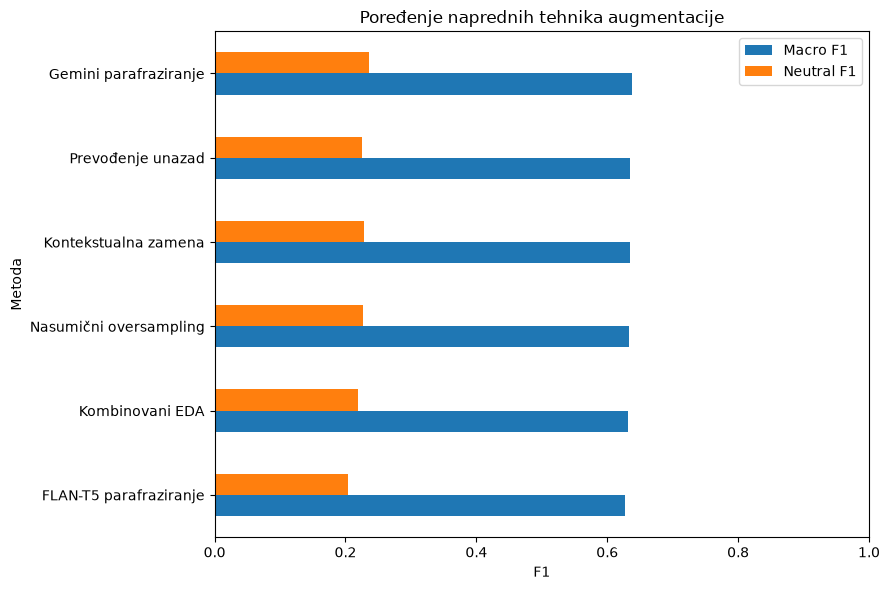

In [26]:
advanced_results.set_index("Metoda")[
    ["Macro F1", "Neutral F1"]
].sort_values("Macro F1").plot(
    kind="barh",
    figsize=(9, 6),
)

plt.xlabel("F1")
plt.title(
    "Poređenje naprednih tehnika augmentacije"
)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 8. Završno poređenje

Rezultati brzih i naprednih metoda nisu direktno poredivi samo po veličini trening skupa, jer koriste različite budžete novih primera. Zbog toga se u zaključku posmatraju dva odvojena eksperimenta:

- **brze metode** – veći budžet `N_QUICK`,
- **napredne metode** – manji i jednak budžet `N_ADVANCED`.

U obe grupe postoji kontrola sa prostim oversamplingom postojećih neutralnih primera.

In [27]:
final_results = pd.DataFrame(
    all_results
)

display(
    final_results[
        [
            "Grupa",
            "Metoda",
            "Broj novih primera",
            "Accuracy",
            "Macro F1",
            "Neutral F1",
            "Generisanje [s]",
        ]
    ].style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "Neutral F1": "{:.3f}",
        "Generisanje [s]": "{:.1f}",
    })
)

,Grupa,Metoda,Broj novih primera,Accuracy,Macro F1,Neutral F1,Generisanje [s]
0,Baseline,Bez augmentacije,0,0.782,0.622,0.188,0.0
1,Brze metode,Nasumični oversampling,1000,0.781,0.646,0.260,0.0
2,Brze metode,Zamena sinonimima,1000,0.778,0.644,0.259,1.9
3,Brze metode,Nasumično umetanje,1000,0.778,0.641,0.246,0.4
4,Brze metode,Nasumično brisanje,1000,0.779,0.643,0.253,0.1
5,Brze metode,Nasumična zamena mesta,1000,0.779,0.647,0.262,0.0
6,Brze metode,Karakterski šum,1000,0.779,0.644,0.256,0.1
7,Brze metode,Kombinovani EDA,1000,0.779,0.647,0.265,0.2
8,Napredne metode,Nasumični oversampling,500,0.780,0.634,0.226,0.0
9,Napredne metode,Kombinovani EDA,500,0.779,0.632,0.220,0.1


## 9. Matrice konfuzije

Za detaljnije tumačenje mogu da se prikažu matrice konfuzije baznog modela i najbolje metode iz grupe naprednih tehnika.

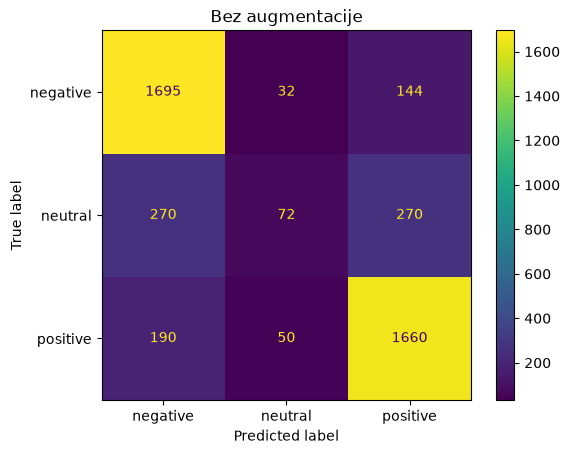

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    experiment_predictions[
        "Baseline | Bez augmentacije"
    ],
    labels=[
        "negative",
        "neutral",
        "positive",
    ],
)

plt.title("Bez augmentacije")
plt.show()

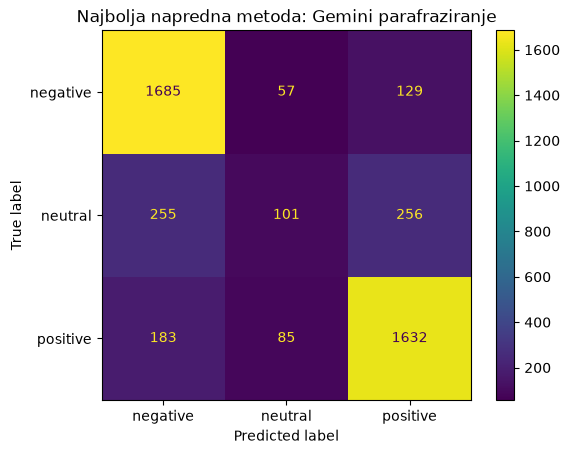

In [29]:
if len(advanced_results) > 0:
    best_advanced_method = (
        advanced_results.iloc[0]["Metoda"]
    )

    key = (
        "Napredne metode | "
        + best_advanced_method
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        experiment_predictions[key],
        labels=[
            "negative",
            "neutral",
            "positive",
        ],
    )

    plt.title(
        "Najbolja napredna metoda: "
        + best_advanced_method
    )
    plt.show()

## 10. Zaključak

Eksperiment omogućava da se uticaj augmentacije proceni pod kontrolisanim uslovima.

Kod brzih metoda ista količina novih podataka generiše se pomoću više EDA transformacija i karakterskog šuma. Nasumični oversampling služi kao kontrola koja pokazuje koliko se rezultat menja samo zbog većeg broja neutralnih primera.

Napredne metode porede se u posebnom eksperimentu sa manjim, jednakim budžetom. U toj grupi nalaze se kontekstualna zamena, prevođenje unazad, FLAN-T5 parafraziranje i Gemini parafraziranje, uz iste kontrole.

Pri izboru najuspešnije tehnike nije dovoljno posmatrati samo `Accuracy`. Posebno su značajni `Macro F1` i `Neutral F1`, jer pokazuju da li je poboljšanje ostvareno i kod manjinske neutralne klase.

Vreme generisanja dodatno pokazuje praktičan kompromis: složenija augmentacija može dati prirodnije primere, ali ne mora obavezno da opravda veći računarski trošak.